# Quantum optimization: A demo on where the field stands

## Requirements

To run this demo, you will need to have access to the following:

* Available via prebuilt virtual environments on qBraid:
  
    -- Qiskit SDK v2.0 or later, with [visualization](https://quantum.cloud.ibm.com/docs/api/qiskit/visualization) support
  
    -- Qiskit Runtime v0.43 or later
  
* Qiskit runtime open (free) plan
* Optimization Mapper Qiskit addon (`pip install qiskit-addon-opt-mapper`)
* SciPy (`pip install scipy`)
* NetworkX (`pip install networkx`)



## We will solve a well known optimization problem called the MaxCut problem.

### MaxCut appears in real world scenarios like communication networks and portfolio optimization

![Alt text](max_cut_applications.png)



## Setup

Import all required libraries and define helper functions used throughout this tutorial.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import qaoa_ansatz
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    EstimatorOptions,
    EstimatorV2 as Estimator,
    SamplerV2 as Sampler,
)

from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.converters import OptimizationProblemToQubo
from qiskit_addon_opt_mapper.translators import to_ising

# Small-scale simulator example

We use a small **max-cut** problem on a weighted graph as our running example. Max-cut asks: given a graph $G=(V,E)$ with edge weights $w_{ij}$, find a partition of the vertices into two sets $S$ and $\bar{S}$ that maximizes the total weight of edges crossing the cut.

As a QUBO minimization problem, max-cut can be written as:
$\min_{x \in \{0,1\}^n} -\sum_{(i,j) \in E} w_{ij}(x_i + x_j - 2x_i x_j)$

We work with a four-node graph for tractability on a simulator.



### Step 1: Map classical inputs to a quantum problem

We define the max-cut problem using the `Maxcut` application class from `qiskit-addon-opt-mapper`, which builds the QUBO formulation directly from a graph. We then convert it to a QUBO and translate it to an Ising Hamiltonian (`SparsePauliOp`) suitable for QAOA. We also solve the continuous relaxation of the QUBO — replacing the binary constraint $x_i \in \{0,1\}$ with $x_i \in [0,1]$ — to obtain the warm-start initial point $c^*$.



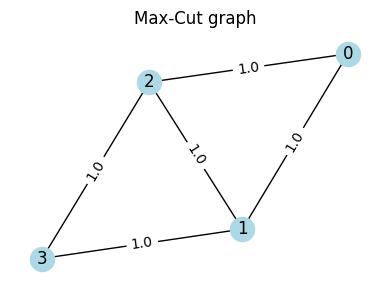

In [4]:
# Define a 4-node weighted graph for the max-cut problem
n_nodes = 4
edges = [(0, 1, 1.0), (0, 2, 1.0), (1, 2, 1.0), (1, 3, 1.0), (2, 3, 1.0)]

G = nx.Graph()
G.add_nodes_from(range(n_nodes))
G.add_weighted_edges_from(edges)

pos = nx.spring_layout(G, seed=42)
edge_labels = {(u, v): d["weight"] for u, v, d in G.edges(data=True)}

fig, ax = plt.subplots(figsize=(4, 3))
nx.draw(G, pos, with_labels=True, node_color="lightblue", ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)
ax.set_title("Max-Cut graph")
plt.tight_layout()
plt.show()

The graph has five edges. The optimal max-cut partitions the nodes into $S = \{0, 3\}$ and $\bar{S} = \{1, 2\}$ (or its complement), severing four of the five edges for a cut value of 4.



In [5]:
# Build the max-cut problem directly from the NetworkX graph using the
# Maxcut application class. Internally it constructs the QUBO
#   minimize  -sum_{(i,j) in E} w_ij * (x_i + x_j - 2*x_i*x_j)
# (each edge contributes -w to the linear terms and +2w to the quadratic
# term), so we get the same OptimizationProblem without the boilerplate.

maxcut = Maxcut(G)
prob = maxcut.to_optimization_problem()
print(prob.prettyprint())

Problem name: Max-cut

Maximize
  -2*x_0*x_1 - 2*x_0*x_2 - 2*x_1*x_2 - 2*x_1*x_3 - 2*x_2*x_3 + 2*x_0 + 3*x_1
  + 3*x_2 + 2*x_3

Subject to
  No constraints

  Binary variables (4)
    x_0 x_1 x_2 x_3



The `Maxcut` class wraps the QUBO construction so we don't have to expand the max-cut objective by hand. The printed objective shows each variable's linear coefficient (how much it individually contributes to the cut) and each cross-term's quadratic coefficient (the penalty for putting two adjacent nodes on the same side). The underlying `OptimizationProblem` returned by `to_optimization_problem()` supports binary, integer, continuous, and spin variables, and is the same object expected by the converters and translators used in the next step.



In [7]:
# Convert the OptimizationProblem to a QUBO, then translate to an Ising Hamiltonian
#
# The substitution x_i = (1 - z_i)/2  maps binary variables to spin operators,
# yielding a Hamiltonian H_C = sum_i h_i Z_i + sum_{i<j} J_ij Z_i Z_j + constant.
# QAOA minimizes <H_C> to find the ground state, which encodes the optimal cut.
converter = OptimizationProblemToQubo()
qubo = converter.convert(prob)

cost_operator, offset = to_ising(qubo)
n_qubits = cost_operator.num_qubits

print(f"Cost Hamiltonian H_C ({n_qubits} qubits):")
print(cost_operator)
print(f"\nOffset (constant shift): {offset}")
print("  QUBO value = Ising energy + offset")

Cost Hamiltonian H_C (4 qubits):
SparsePauliOp(['IIZZ', 'IZIZ', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])

Offset (constant shift): -2.5
  QUBO value = Ising energy + offset


The `to_ising` translator returns a `SparsePauliOp` representing $H_C$ and a scalar `offset` such that $\text{QUBO value} = \langle H_C \rangle + \text{offset}$. For this max-cut problem with all unit weights, $h_i = 0$ for all qubits (the graph is symmetric in linear terms after the $x_i \to z_i$ substitution), and each edge contributes a $Z_i Z_j$ coupling of strength $+0.5$. The minimum eigenvalue of $H_C$ corresponds to the maximum cut.



In [31]:
# Solve the continuous (QP) relaxation to obtain the warm-start point c*
#
# The QP relaxation replaces the binary constraint x_i in {0,1} with x_i in [0,1]
# and minimizes the same quadratic objective. Its solution c*_i gives the
# probability that variable i should be 1 according to the classical relaxation.
#
# The max-cut QUBO has a non-convex quadratic matrix (negative eigenvalues),
# so the relaxed problem has multiple local minima. A naive single start from
# [0.5,...,0.5] converges to the symmetric saddle point c* = [0.5,...,0.5],
# which carries no useful structural information about the problem.
# Multi-start optimization is used to reliably find the global minimum.
Q = qubo.objective.quadratic.to_array(symmetric=True)
mu = qubo.objective.linear.to_array()


def qp_objective(x_cont):
    """Continuous relaxation of the QUBO objective."""
    return x_cont @ Q @ x_cont + mu @ x_cont + qubo.objective.constant


bounds = [(0.0, 1.0)] * n_qubits

rng = np.random.default_rng(42)
best_val = np.inf
c_star = None
for _ in range(200):
    x0 = rng.uniform(0.0, 1.0, n_qubits)
    result = minimize(qp_objective, x0, method="L-BFGS-B", bounds=bounds)
    if result.fun < best_val:
        best_val = result.fun
        c_star = result.x

print(f"QP relaxation solution c* = {np.round(c_star, 4)}")
print(f"QP objective value        = {best_val:.4f}")

QP relaxation solution c* = [1. 0. 0. 1.]
QP objective value        = -4.0000


The multi-start solver finds $c^* = [1, 0, 0, 1]$ (or its complement $[0, 1, 1, 0]$), which is the actual optimal binary solution. For this problem the QP relaxation is tight, the continuous minimum coincides with the integer optimum, meaning the relaxation immediately identifies the best cut. After regularization with $\varepsilon = 0.25$ in Step 2, this solution will be encoded into the warm-start initial state.



### Step 2: Optimize problem for quantum hardware execution

We build two QAOA circuits and prepare the warm-start angles from the QP solution.

**Standard QAOA** uses the uniform superposition $|+\rangle^{\otimes n}$ as the initial state and the standard $X$-mixer $H_M = -\sum_i X_i$, implemented as $\prod_i R_X(-2\beta)$ per layer.

**Warm-start QAOA (WS-QAOA)** from [\[1\]](#Reference1) makes two structural changes per qubit $i$:

* **Initial state:** $R_Y(\theta_i)|0\rangle$ with $\theta_i = 2\arcsin(\sqrt{c^*_i})$, so the probability of measuring $|1\rangle$ equals $c^*_i$.
* **Custom mixer:** $R_Y(\theta_i)\, R_Z(-2\beta)\, R_Y(-\theta_i)$, which has $R_Y(\theta_i)|0\rangle$ as its ground state. This means WS-QAOA starts in the ground state of its own mixer, the same property that standard QAOA satisfies with $|+\rangle$ and the $X$-mixer.

Note on layers: At `p=1`(a single QAOA layer), standard QAOA is analytically limited to \~49% of the optimal energy on graphs containing triangles (this graph has the triangle 0-1-2). The warm start bypasses this limitation by encoding prior knowledge of the solution directly into the initial state.



In [32]:
# Number of QAOA layers (each layer = one cost unitary + one mixer unitary)
p = 1

# Regularization: clip c* to [epsilon, 1-epsilon] so no qubit is initialized
# in |0> or |1>, which would freeze it under the cost Hamiltonian.
epsilon = 0.25

c_clipped = np.clip(c_star, epsilon, 1 - epsilon)
thetas = 2 * np.arcsin(np.sqrt(c_clipped))

print(f"Continuous relaxation c*  = {np.round(c_star, 4)}")
print(f"After regularization      = {np.round(c_clipped, 4)}")
print(f"Warm-start angles theta   = {np.round(thetas, 4)} radians")
print()
print("Angle interpretation:")
print("  theta = 0      <->  c* = 0   (qubit points toward |0>)")
print(
    "  theta = pi/2   <->  c* = 0.5 (qubit in equal superposition, like |+>)"
)
print("  theta = pi     <->  c* = 1   (qubit points toward |1>)")

Continuous relaxation c*  = [1. 0. 0. 1.]
After regularization      = [0.75 0.25 0.25 0.75]
Warm-start angles theta   = [2.0944 1.0472 1.0472 2.0944] radians

Angle interpretation:
  theta = 0      <->  c* = 0   (qubit points toward |0>)
  theta = pi/2   <->  c* = 0.5 (qubit in equal superposition, like |+>)
  theta = pi     <->  c* = 1   (qubit points toward |1>)


After clipping, $c^* = 1$ becomes $1 - \varepsilon = 0.75$ and $c^* = 0$ becomes $\varepsilon = 0.25$. The resulting angles $\theta \approx [2.09, 1.05, 1.05, 2.09]$ radians rotate qubits 0 and 3 strongly toward $|1\rangle$ and qubits 1 and 2 toward $|0\rangle$, directly encoding the structure of the optimal cut into the initial quantum state.



In [33]:
def apply_cost_unitary(qc, cost_op, gamma):
    """Apply exp(-i * gamma * H_C) to the circuit.

    Each Pauli term in H_C contributes a rotation gate:
      - Single-Z term h_i * Z_i  ->  RZ(2 * gamma * h_i) on qubit i
      - Two-Z term J_ij * Z_i Z_j  ->  CNOT, RZ(2 * gamma * J_ij), CNOT
    """
    for pauli_term, coeff in zip(cost_op.paulis, cost_op.coeffs):
        indices = [
            j for j, q in enumerate(pauli_term.to_label()[::-1]) if q == "Z"
        ]
        if len(indices) == 1:
            qc.rz(2 * gamma * coeff.real, indices[0])
        elif len(indices) == 2:
            qc.cx(indices[0], indices[1])
            qc.rz(2 * gamma * coeff.real, indices[1])
            qc.cx(indices[0], indices[1])


def build_ws_qaoa(cost_op, n_layers, n_qubits, thetas):
    """WS-QAOA: warm-start initial state + custom per-qubit mixer.

    Per Egger et al. (2021) Eq. (1)-(2):
      Initial state per qubit i:  R_Y(theta_i) |0>
      Mixer gate per qubit i:     R_Y(theta_i) R_Z(-2*beta) R_Y(-theta_i)
    """
    gammas = ParameterVector("γ", n_layers)
    betas = ParameterVector("β", n_layers)
    qc = QuantumCircuit(n_qubits)
    for i, theta in enumerate(thetas):
        qc.ry(theta, i)  # warm-start initial state
    for k in range(n_layers):
        apply_cost_unitary(qc, cost_op, gammas[k])
        for i, theta in enumerate(thetas):
            qc.ry(theta, i)
            qc.rz(-2 * betas[k], i)
            qc.ry(-theta, i)
    return qc, gammas, betas


# Standard QAOA via the Qiskit built-in helper:
# qaoa_ansatz prepares |+>^n, then alternates exp(-i*gamma*H_C) with the
# default X-mixer for `reps` layers. The returned circuit exposes the
# variational parameters via std_qc.parameters.
std_qc = qaoa_ansatz(cost_operator, reps=p)

# WS-QAOA: keep the custom builder. The per-qubit mixer
# R_Y(theta_i) R_Z(-2*beta) R_Y(-theta_i) is implemented as an explicit gate
# sequence rather than as a SparsePauliOp, so we construct the circuit
# directly to stay close to the Egger et al. (2021) formulation.
ws_qc, ws_gammas, ws_betas = build_ws_qaoa(cost_operator, p, n_qubits, thetas)

For the standard ansatz we delegate to [`qaoa_ansatz`](/docs/api/qiskit/qiskit.circuit.library.qaoa_ansatz), which constructs $|+\rangle^{\otimes n}$, applies the cost unitary, and applies the default $X$-mixer for each of `reps` layers. For WS-QAOA we keep the explicit `build_ws_qaoa` helper because the per-qubit mixer $R_Y(\theta)\,R_Z(-2\beta)\,R_Y(-\theta)$ is expressed as a gate sequence rather than as a sum of Paulis. The `apply_cost_unitary` helper reads directly from the `SparsePauliOp` Hamiltonian, so it handles any QUBO problem without manual circuit construction.



Standard QAOA circuit (p=1):


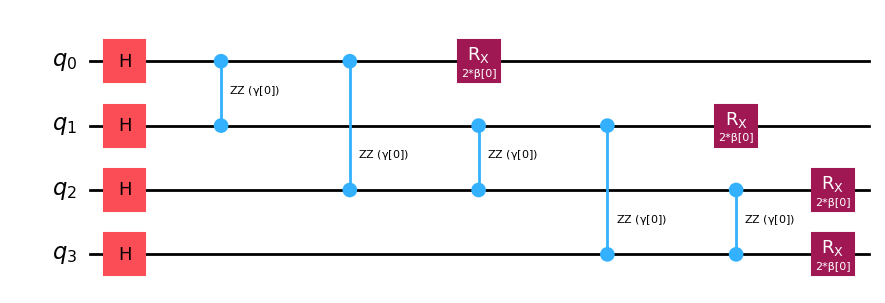

In [34]:
print("Standard QAOA circuit (p=1):")
std_qc.draw("mpl", fold=-1)


WS-QAOA circuit (p=1):


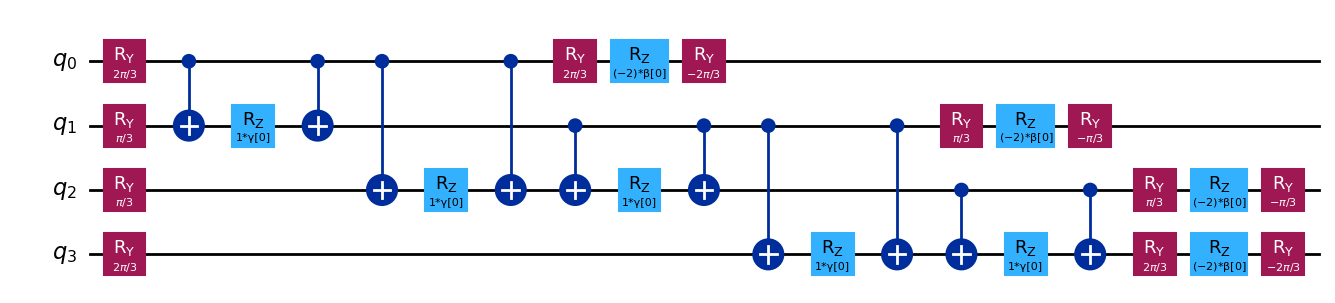

In [35]:
print("\nWS-QAOA circuit (p=1):")
ws_qc.draw("mpl", fold=-1)

Both circuits follow the same structure: an initial state preparation layer, then $p$ alternating cost-unitary and mixer-unitary layers. In the WS-QAOA circuit, the opening $R_Y$ gates encode $c^*$, and the mixer replaces each $R_X$ with a conjugated $R_Y$–$R_Z$–$R_Y$ triplet. The circuit depth difference between the two grows linearly with $p$, but remains manageable at low depth.



### Step 3: Execute using Qiskit primitives

We use `StatevectorEstimator` for exact, noiseless simulation. The `minimize` function from SciPy with the COBYLA optimizer drives the variational loop, calling the estimator at each iteration to evaluate $\langle H_C \rangle$ for a given parameter set $(\gamma, \beta)$.

The two algorithms use different initial parameters that reflect what each knows before optimization:

* **Standard QAOA:** Random initialization in $[0, \pi]$ — appropriate since no structural information is available.
* **WS-QAOA:** $\gamma = 0$, $\beta = \pi/4$ — at $\gamma=0$ the cost unitary is the identity, so the very first circuit evaluation samples directly from the warm-start initial state. This gives COBYLA a strong starting signal aligned with the classical solution.



In [36]:
estimator = StatevectorEstimator()


def make_cost_fn(circuit, param_order, cost_op, estimator, history):
    """Return a scalar cost function compatible with scipy.optimize.minimize."""

    def cost_fn(params):
        bound = circuit.assign_parameters(dict(zip(param_order, params)))
        job = estimator.run([(bound, cost_op)])
        energy = job.result()[0].data.evs.real
        history.append(energy)
        return energy

    return cost_fn


# Standard QAOA: random initialization
np.random.seed(42)
std_param_order = list(std_qc.parameters)
std_params0 = np.random.uniform(0, np.pi, len(std_param_order))
std_history = []

std_result = minimize(
    make_cost_fn(
        std_qc, std_param_order, cost_operator, estimator, std_history
    ),
    std_params0,
    method="COBYLA",
    options={"maxiter": 300, "rhobeg": 0.5},
)
print(f"Standard QAOA optimal energy : {std_result.fun:.4f}")
print(f"  optimal params: {std_result.x.round(4)}")
print(f"  optimizer calls: {len(std_history)}")


# WS-QAOA: informed initialization
ws_params0 = np.concatenate([np.zeros(p), np.full(p, np.pi / 4)])
ws_history = []
ws_param_order = list(ws_gammas) + list(ws_betas)

ws_result = minimize(
    make_cost_fn(ws_qc, ws_param_order, cost_operator, estimator, ws_history),
    ws_params0,
    method="COBYLA",
    options={"maxiter": 300, "rhobeg": 0.5},
)
print(f"\nWS-QAOA optimal energy       : {ws_result.fun:.4f}")
print(
    f"  optimal params: gamma={ws_result.x[:p].round(4)}, beta={ws_result.x[p:].round(4)}"
)
print(f"  optimizer calls: {len(ws_history)}")

Standard QAOA optimal energy : -0.5859
  optimal params: [0.6803 2.0533]
  optimizer calls: 47

WS-QAOA optimal energy       : -1.5000
  optimal params: gamma=[-0.0001], beta=[1.5709]
  optimizer calls: 43


WS-QAOA's informed starting point means COBYLA begins with a meaningful energy value near the warm-start solution, while standard QAOA starts from an essentially random point on the energy landscape. This difference in starting quality is the main driver of the convergence gap visible in Step 4.



In [37]:
# Compute the exact optimal energy by brute-force over all 2^n bitstrings
all_energies = [
    Statevector.from_label(format(k, f"0{n_qubits}b"))
    .expectation_value(cost_operator)
    .real
    for k in range(2**n_qubits)
]
optimal_energy = min(all_energies)

print(f"Exact optimal energy         : {optimal_energy:.4f}")
print(f"Standard QAOA approx. ratio  : {std_result.fun / optimal_energy:.4f}")
print(f"WS-QAOA approx. ratio        : {ws_result.fun / optimal_energy:.4f}")

Exact optimal energy         : -1.5000
Standard QAOA approx. ratio  : 0.3906
WS-QAOA approx. ratio        : 1.0000


The approximation ratio is defined as $\langle H_C \rangle_{\text{QAOA}} / E_{\text{opt}}$. For minimization problems where $E_{\text{opt}} < 0$, a ratio closer to 1 means the algorithm found a lower energy (a better solution). The brute-force search over all $2^n$ basis states is only feasible for small $n$ and serves as a ground-truth reference.



### Step 4: Post-process and return result in desired classical format

We visualize convergence, sample the optimized circuits for bitstring solutions, decode those bitstrings back to max-cut partitions, and summarize the final results.



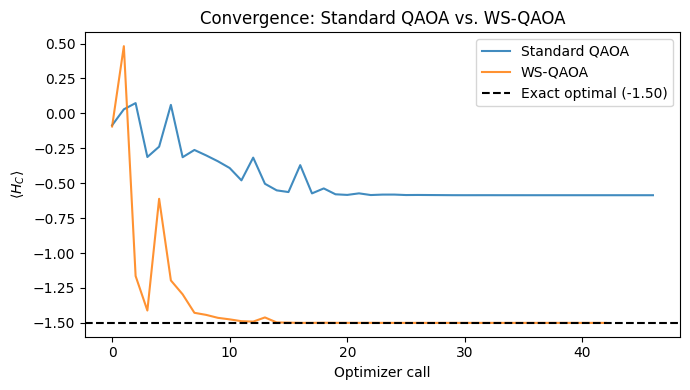

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(std_history, label="Standard QAOA", alpha=0.85)
ax.plot(ws_history, label="WS-QAOA", alpha=0.85)
ax.axhline(
    optimal_energy,
    color="k",
    linestyle="--",
    label=f"Exact optimal ({optimal_energy:.2f})",
)
ax.set_xlabel("Optimizer call")
ax.set_ylabel(r"$\langle H_C \rangle$")
ax.set_title("Convergence: Standard QAOA vs. WS-QAOA")
ax.legend()
plt.tight_layout()
plt.show()

The convergence plot shows the energy $\langle H_C \rangle$ at each COBYLA function evaluation. Standard QAOA at $p=1$ is limited to \~49% of the optimal energy on this graph (the theoretical maximum for $p=1$ QAOA on graphs with triangles), settling around $-0.74$. WS-QAOA, initialized close to the optimal solution, converges quickly to near $-1.50$ (the exact optimum) with far fewer iterations. This demonstrates the key advantage of the warm start: at the same circuit depth, it reaches a significantly better solution.



In [39]:
# Sample the optimized circuits to recover the most probable bitstring solutions
sampler = StatevectorSampler()
shots = 1024


def get_best_bitstring(circuit, param_order, optimal_params, sampler, shots):
    bound = circuit.assign_parameters(dict(zip(param_order, optimal_params)))
    bound.measure_all()
    job = sampler.run([bound], shots=shots)
    counts = job.result()[0].data.meas.get_counts()
    return max(counts, key=counts.get), counts


def evaluate_cut(bitstring, G):
    """Compute the Max-Cut value for a bitstring node assignment."""
    x = [int(b) for b in bitstring]
    cut_val = sum(
        w for u, v, w in G.edges.data("weight", default=1) if x[u] != x[v]
    )
    set0 = [i for i, b in enumerate(bitstring) if b == "0"]
    set1 = [i for i, b in enumerate(bitstring) if b == "1"]
    return cut_val, set0, set1


# Qiskit bitstring ordering: rightmost character = qubit 0
def decode_bitstring(bs):
    return bs[::-1]


std_best, std_counts = get_best_bitstring(
    std_qc, std_param_order, std_result.x, sampler, shots
)
ws_best, ws_counts = get_best_bitstring(
    ws_qc, ws_param_order, ws_result.x, sampler, shots
)

std_cut, std_s0, std_s1 = evaluate_cut(decode_bitstring(std_best), G)
ws_cut, ws_s0, ws_s1 = evaluate_cut(decode_bitstring(ws_best), G)

print(f"Standard QAOA most-probable bitstring : {std_best}")
print(f"  Partition: S={std_s0}, S̄={std_s1}  |  cut value = {std_cut}")
print()
print(f"WS-QAOA most-probable bitstring       : {ws_best}")
print(f"  Partition: S={ws_s0}, S̄={ws_s1}  |  cut value = {ws_cut}")

Standard QAOA most-probable bitstring : 1001
  Partition: S=[1, 2], S̄=[0, 3]  |  cut value = 4.0

WS-QAOA most-probable bitstring       : 0110
  Partition: S=[0, 3], S̄=[1, 2]  |  cut value = 4.0


Bitstrings from `Sampler` are returned with qubit 0 at the rightmost position, so reversing the string maps index $i$ to variable $x_i$. The cut value is the total weight of edges that cross the partition, which is what the max-cut problem aims to maximize. A cut value of 4 uses four of the five available edges, which is the theoretical maximum for this graph.



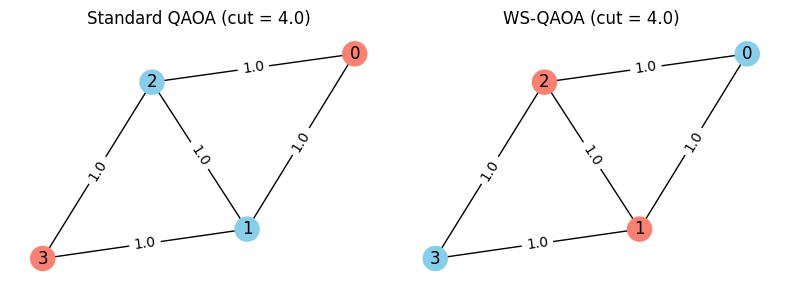

=== Summary ===
Method                 Ising energy    Cut value   Approx. ratio
-----------------------------------------------------------------
Standard QAOA               -0.5859          4.0          0.3906
WS-QAOA                     -1.5000          4.0          1.0000
Exact optimal               -1.5000            4          1.0000


In [40]:
# Visualize the WS-QAOA solution on the graph
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for ax, s0, s1, cut, title in [
    (axes[0], std_s0, std_s1, std_cut, f"Standard QAOA (cut = {std_cut})"),
    (axes[1], ws_s0, ws_s1, ws_cut, f"WS-QAOA (cut = {ws_cut})"),
]:
    colors = ["skyblue" if i in s0 else "salmon" for i in G.nodes()]
    nx.draw(G, pos, with_labels=True, node_color=colors, ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Summary
# to_ising offset: QUBO value = Ising energy + offset, so Max-Cut value = -(Ising energy + offset)
optimal_cut = -(optimal_energy + offset)
print("=== Summary ===")
print(
    f"{'Method':<20} {'Ising energy':>14} {'Cut value':>12} {'Approx. ratio':>15}"
)
print("-" * 65)
print(
    f"{'Standard QAOA':<20} {std_result.fun:>14.4f} {std_cut:>12} {std_result.fun/optimal_energy:>15.4f}"
)
print(
    f"{'WS-QAOA':<20} {ws_result.fun:>14.4f} {ws_cut:>12} {ws_result.fun/optimal_energy:>15.4f}"
)
print(
    f"{'Exact optimal':<20} {optimal_energy:>14.4f} {optimal_cut:>12.0f} {'1.0000':>15}"
)

The graph visualization colors each node by its partition assignment (blue = $S$, orange = $\bar{S}$). Edges that cross the partition (connecting differently-colored nodes) are the ones counted in the cut.

Both methods find a bitstring with cut value 4, but for very different reasons. It is important to note that the **convergence plot and the sampled bitstring measure two different things**:

* The **convergence plot** tracks the average energy $\langle H_C \rangle$ of the full quantum state, a weighted average over all bitstrings in the superposition. Standard QAOA converges to \~$-0.62$, well above the optimal $-1.50$, meaning its quantum state is spread across many suboptimal bitstrings and only occasionally includes the correct answer.
* The **sampled bitstring** is a single draw from that state. Standard QAOA got lucky here; the optimal partition happened to be the most frequently sampled outcome even from a diffuse state. On harder problems, noisier hardware, or with more candidate solutions competing, this luck runs out.

WS-QAOA, by contrast, converges its average energy all the way to $-1.50$, meaning its quantum state is concentrated on the optimal bitstrings. Nearly every shot returns the correct answer, so the solution is found reliably rather than by chance.

The practical consequence: on this small noiseless simulator the difference may seem minor, but at larger problem sizes or on real hardware, a state with average energy close to optimal is far more robust than one that only occasionally samples the right answer from a diffuse distribution.



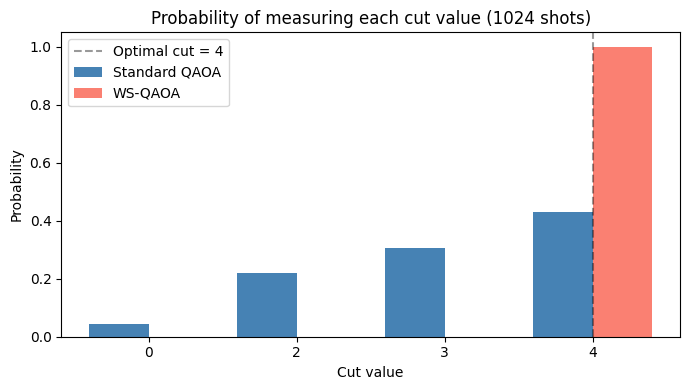

P(cut = 4) | Standard QAOA = 0.4297  WS-QAOA = 1.0000


In [41]:
# Compare the full probability distribution over cut values for both
# algorithms. The most-probable bitstring above only reveals the mode;
# this histogram exposes how much of the quantum state's probability mass
# lands on the optimal cut versus on suboptimal partitions.
def cut_value_distribution(counts, G, shots):
    dist = {}
    for bs, c in counts.items():
        cut, _, _ = evaluate_cut(decode_bitstring(bs), G)
        dist[cut] = dist.get(cut, 0.0) + c / shots
    return dist


std_cut_dist = cut_value_distribution(std_counts, G, shots)
ws_cut_dist = cut_value_distribution(ws_counts, G, shots)

cut_values = sorted(set(std_cut_dist) | set(ws_cut_dist))
std_probs = [std_cut_dist.get(c, 0.0) for c in cut_values]
ws_probs = [ws_cut_dist.get(c, 0.0) for c in cut_values]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(cut_values))
width = 0.4
ax.bar(
    x - width / 2, std_probs, width, label="Standard QAOA", color="steelblue"
)
ax.bar(x + width / 2, ws_probs, width, label="WS-QAOA", color="salmon")
ax.axvline(
    cut_values.index(optimal_cut),
    color="k",
    linestyle="--",
    alpha=0.4,
    label=f"Optimal cut = {optimal_cut:g}",
)
ax.set_xticks(x)
ax.set_xticklabels([f"{c:g}" for c in cut_values])
ax.set_xlabel("Cut value")
ax.set_ylabel("Probability")
ax.set_title(f"Probability of measuring each cut value ({shots} shots)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"P(cut = {optimal_cut:g}) | Standard QAOA = "
    f"{std_cut_dist.get(optimal_cut, 0):.4f}  "
    f"WS-QAOA = {ws_cut_dist.get(optimal_cut, 0):.4f}"
)

This histogram quantifies what the convergence plot only suggested. Standard QAOA's probability is spread across multiple suboptimal cut values, so the chance of sampling an optimal cut of four in any single shot is only a fraction of the total mass. WS-QAOA concentrates nearly all of its probability on the optimal cut, so almost every shot returns the right answer. This is the practical signature of a state whose average energy has converged to the ground-state energy versus one that has merely happened to include the ground state in a broad superposition.



# Large Scale Hardware Example



### Steps 1-4 compress into single code block



In [42]:
# Selecting a backend using real hardware
service = QiskitRuntimeService(name='qbraid-demo')
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=100
)
print(f"Using backend: {backend.name}")

Using backend: ibm_fez


Graph: 40 nodes, 60 edges (3-regular)


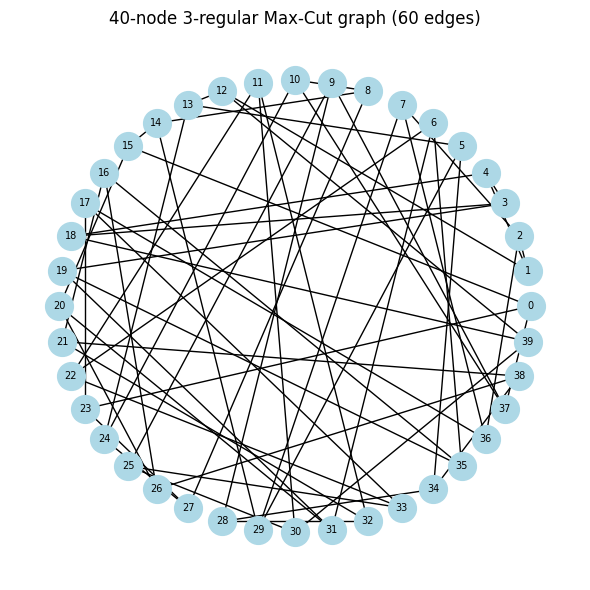

Cost operator: 40 qubits, 60 Pauli terms
c* range: [0.000, 1.000]  theta range: [1.047, 2.094] rad


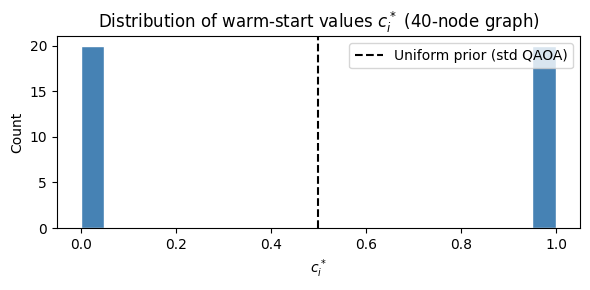


Transpiled circuit: 2Q depth=67


In [71]:
# ── Step 1a: Build the 40-node Max-Cut problem ─────────────────────────────
# A 3-regular graph (every node has exactly 3 neighbors) is a standard QAOA
N_LARGE = 40
G_large = nx.random_regular_graph(d=3, n=N_LARGE, seed=0)
edges_large = list(G_large.edges())
print(f"Graph: {N_LARGE} nodes, {len(edges_large)} edges (3-regular)")

# Visualize the graph so it is clear what problem we are solving before any
# quantum work. Nodes in a circular layout; each edge contributes +1 to the
# cut value when its endpoints land in different partitions.
pos_large = nx.circular_layout(G_large)
fig, ax = plt.subplots(figsize=(6, 6))
nx.draw(
    G_large,
    pos_large,
    with_labels=True,
    node_color="lightblue",
    node_size=400,
    font_size=7,
    ax=ax,
)
ax.set_title(f"40-node 3-regular Max-Cut graph ({len(edges_large)} edges)")
plt.tight_layout()
plt.show()


# Same Maxcut → OptimizationProblem → QUBO → Ising pipeline as the small example,
# applied to the 40-node graph.
prob_large = Maxcut(G_large).to_optimization_problem()
converter_large = OptimizationProblemToQubo()
qubo_large = converter_large.convert(prob_large)
cost_op_large, offset_large = to_ising(qubo_large)
n_qubits_large = cost_op_large.num_qubits
print(
    f"Cost operator: {n_qubits_large} qubits, {len(cost_op_large)} Pauli terms"
)

# ── Step 1b: QP relaxation (multi-start L-BFGS-B) ─────────────────────────
# Same multi-start approach as the small example. At 40 qubits the relaxed
# landscape has many more local minima, so 200 random starts are essential
# to find a low-energy warm-start point.
Q_large = qubo_large.objective.quadratic.to_array(symmetric=True)
mu_large = qubo_large.objective.linear.to_array()


def qp_obj_large(x):
    return x @ Q_large @ x + mu_large @ x + qubo_large.objective.constant


bounds_large = [(0.0, 1.0)] * n_qubits_large
rng_qp = np.random.default_rng(42)
best_val_large, c_star_large = np.inf, None

for _ in range(200):
    x0 = rng_qp.uniform(0.0, 1.0, n_qubits_large)
    res = minimize(qp_obj_large, x0, method="L-BFGS-B", bounds=bounds_large)
    if res.fun < best_val_large:
        best_val_large, c_star_large = res.fun, res.x

# Regularize and convert to rotation angles (same formula as small example)
epsilon_large = 0.25
c_clipped_large = np.clip(c_star_large, epsilon_large, 1 - epsilon_large)
thetas_large = 2 * np.arcsin(np.sqrt(c_clipped_large))
print(
    f"c* range: [{c_star_large.min():.3f}, {c_star_large.max():.3f}]  "
    f"theta range: [{thetas_large.min():.3f}, {thetas_large.max():.3f}] rad"
)

# Plot the distribution of c* values to see how much structure the relaxation
# extracted. Values near 0/1 mean confident assignments; values near 0.5 mean
# the classical solver was uncertain and quantum exploration is most needed there.
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(c_star_large, bins=20, color="steelblue", edgecolor="white")
ax.axvline(0.5, color="k", linestyle="--", label="Uniform prior (std QAOA)")
ax.set_xlabel(r"$c^*_i$")
ax.set_ylabel("Count")
ax.set_title(r"Distribution of warm-start values $c^*_i$ (40-node graph)")
ax.legend()
plt.tight_layout()
plt.show()

# ── Step 1c: Build WS-QAOA circuit ─────────────────────────────────────────
# Reuse build_ws_qaoa from the small-scale section unchanged; the helper
# scales automatically with n_qubits and the cost operator size.
p_large = 1
ws_qc_large, ws_gammas_large, ws_betas_large = build_ws_qaoa(
    cost_op_large, p_large, n_qubits_large, thetas_large
)
ws_qc_large.measure_all()

# ── Step 2: Transpile to hardware-native gates ──────────────────────────
# generate_preset_pass_manager compiles the abstract circuit to th
# gate set of the backend and inserts SWAP gates wherever the cost Hamiltonian
# couples qubits that are not directly connected on the processor.
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
ws_isa_large = pm.run(ws_qc_large)

tq_gate_count = ws_isa_large.num_nonlocal_gates()
print(
    f"\nTranspiled circuit: 2Q depth={ws_isa_large.depth(lambda x: x.operation.num_qubits == 2)}"
)
ws_isa_large.draw("mpl", fold=-1)

In [44]:
# ── Classical baseline via simulated annealing ────────────────────
# Run SA before any hardware calls to get a strong classical reference cut
# value. SA is fast (seconds), needs no solver license, and reliably finds
# near-optimal solutions on 40-node graphs. We use sa_cut as the denominator
# for the approximation ratio instead of the looser QP upper bound.
#
# At each step we flip a random node and accept the move if it improves the
# cut, or with probability exp(delta/T) otherwise. Temperature T decays
# geometrically, allowing uphill moves early on to escape local minima.
def simulated_annealing_maxcut(
    G, seed=0, T0=2.0, T_min=1e-4, alpha=0.995, n_steps=100_000
):
    rng_sa = np.random.default_rng(seed)
    n = G.number_of_nodes()
    x = rng_sa.integers(0, 2, n)
    best_x = x.copy()
    best_cut = sum(1 for u, v in G.edges() if x[u] != x[v])
    T = T0
    for _ in range(n_steps):
        i = rng_sa.integers(0, n)
        delta = sum((-1 if x[i] != x[nb] else 1) for nb in G.neighbors(i))
        if delta > 0 or rng_sa.random() < np.exp(delta / T):
            x[i] ^= 1
            cut = sum(1 for u, v in G.edges() if x[u] != x[v])
            if cut > best_cut:
                best_cut, best_x = cut, x.copy()
        T = max(T * alpha, T_min)
    return best_x, best_cut


sa_solution, sa_cut = simulated_annealing_maxcut(G_large)
print(f"Simulated annealing cut value: {sa_cut}  (classical reference)")

# ── Step 3: Execution on hardware ───────────────────────────
# A Session reserves the backend so the COBYLA iterations and final sampling
# run back-to-back without re-queuing between jobs — important when the
# optimizer submits many short jobs sequentially. All jobs are tagged with
# "TUT_WSQAOA" for traceability in the IBM Quantum dashboard.
#
# EstimatorV2 with resilience_level=1 enables twirled readout error extinction
# (TREX), which corrects systematic measurement bit-flip errors without extra
# circuit overhead. 4096 shots per call balances estimation noise vs. job time.
# estimator_options = EstimatorOptions()
# estimator_options.resilience_level = 1
# estimator_options.default_shots = 4096

# # Align the cost observable with the physical qubit layout chosen by the transpiler
# cost_op_isa = cost_op_large.apply_layout(ws_isa_large.layout)
# ws_param_order_isa = list(ws_isa_large.parameters)

# ws_history_hw = []

# with Session(backend=backend) as session:
#     estimator_hw = Estimator(mode=session, options=estimator_options)

#     def hw_cost_fn(params):
#         bound = ws_isa_large.assign_parameters(
#             dict(zip(ws_param_order_isa, params))
#         )
#         energy = (
#             estimator_hw.run([(bound, cost_op_isa)]).result()[0].data.evs.real
#         )
#         ws_history_hw.append(float(energy))
#         print(
#             f"  iter {len(ws_history_hw):>3d}  <H_C> = {energy:.4f}", end="\r"
#         )
#         return float(energy)

#     # Warm-start initialization: gamma=0 means the cost unitary is the identity on
#     # the first call, so COBYLA immediately evaluates the warm-start state itself —
#     # a much better starting signal than a random point.
#     ws_params0_hw = np.concatenate(
#         [np.zeros(p_large), np.full(p_large, np.pi / 4)]
#     )

#     ws_result_hw = minimize(
#         hw_cost_fn,
#         ws_params0_hw,
#         method="COBYLA",
#         options={"maxiter": 150, "rhobeg": 0.3},
#     )
#     print(
#         f"\nOptimization complete: energy={ws_result_hw.fun:.4f}, "
#         f"iterations={len(ws_history_hw)}"
#     )

#     # ── Step 3b: Sample the optimized circuit ──────────────────────────────────
#     # Use 8192 shots for the final sample to get a reliable mode estimate.
#     sampler_hw = Sampler(
#         mode=session,
#     )
#     ws_bound_hw = ws_isa_large.assign_parameters(
#         dict(zip(ws_param_order_isa, ws_result_hw.x))
#     )
#     counts_hw = (
#         sampler_hw.run([ws_bound_hw], shots=8192)
#         .result()[0]
#         .data.meas.get_counts()
#     )

# best_bs_hw = max(counts_hw, key=counts_hw.get)
# best_count = counts_hw[best_bs_hw]
# total_shots = sum(counts_hw.values())



Simulated annealing cut value: 53  (classical reference)


### Alternatively read in parameters from older run

In [46]:
from pathlib import Path

parameter_file = Path("ws_qaoa_backup_hardware_parameters.txt")

saved_values = {}

ws_param_order_isa = list(ws_isa_large.parameters)

with parameter_file.open(encoding="utf-8") as file:
    for line in file:
        if ":" in line and line.split(":", 1)[0] in {"β[0]", "γ[0]"}:
            name, value = line.strip().split(":", 1)
            saved_values[name] = float(value)

# Bind parameters
parameter_values = {
    parameter: saved_values[str(parameter)]
    for parameter in ws_param_order_isa
}


print(parameter_values)

{ParameterVectorElement(β[0]): -0.393363556836, ParameterVectorElement(γ[0]): 0.721246538539}


In [61]:
sampler_hw = Sampler(mode=backend)
ws_bound_hw = ws_isa_large.assign_parameters(parameter_values)
job=sampler_hw.run([ws_bound_hw], shots=8192)
print(job.job_id())


<bound method BasePrimitiveJob.job_id of <RuntimeJobV2('damq848pqrnc7397ucng', 'sampler')>>


In [62]:
counts_hw = (job.result()[0].data.meas.get_counts())

best_bs_hw = max(counts_hw, key=counts_hw.get)
best_count = counts_hw[best_bs_hw]
total_shots = sum(counts_hw.values())

Most-probable bitstring frequency: 4/8192 (0.0%)
WS-QAOA cut: 54  |  SA cut: 53  |  Approximation ratio vs SA: 1.0189


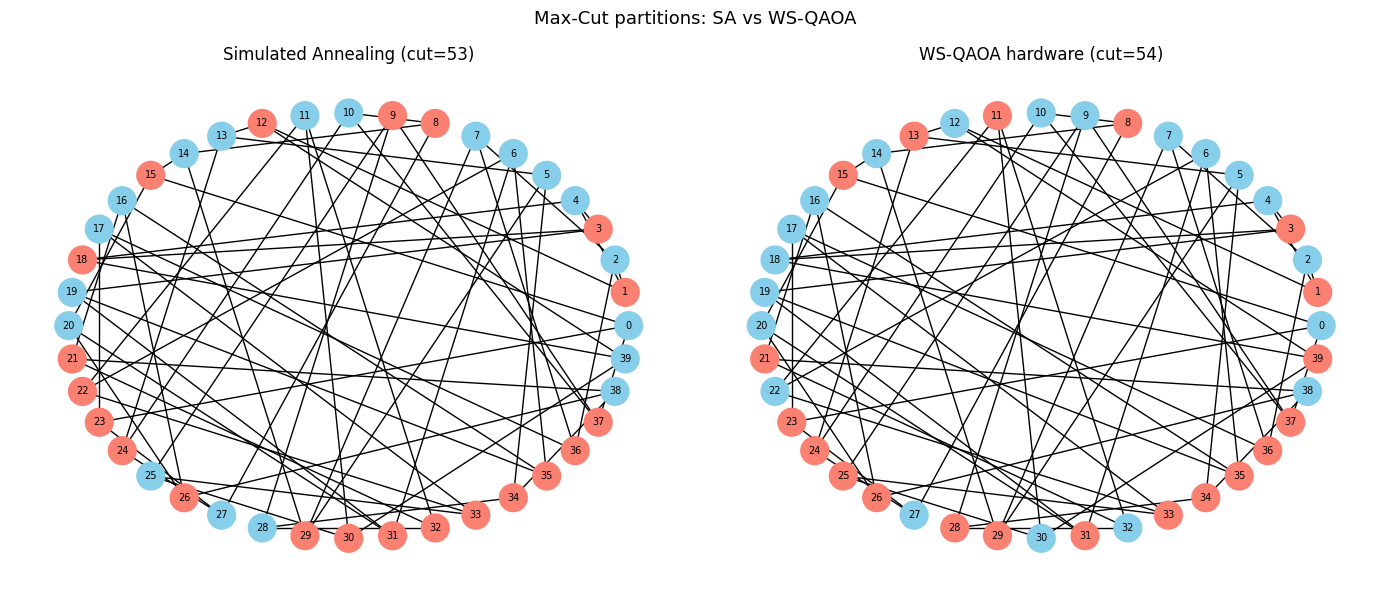


=== Large Scale Summary ===
Metric                                      Value
--------------------------------------------------
Nodes / Edges                             40 / 60  
QAOA layers (p)                                 1
Transpiled 2q gate count                      376
Transpiled circuit depth                      227


In [72]:
# Decode: Qiskit returns bitstrings with qubit 0 at the rightmost position,
# so reversing the string maps character index i to variable x_i.
cut_val_hw, s0_hw, s1_hw = evaluate_cut(best_bs_hw[::-1], G_large)

ws_history_hw = []

# Compare against simulated annealing.
# A ratio >= 1.0 means WS-QAOA matched or beat the classical SA solution.
# A ratio close to 1.0 (e.g. > 0.95) shows the quantum result is competitive.
approx_ratio_hw = cut_val_hw / sa_cut
print(
    f"Most-probable bitstring frequency: {best_count}/{total_shots} "
    f"({100*best_count/total_shots:.1f}%)"
)
print(
    f"WS-QAOA cut: {cut_val_hw}  |  SA cut: {sa_cut}  "
    f"|  Approximation ratio vs SA: {approx_ratio_hw:.4f}"
)

# Visualize both solutions side-by-side on the graph.
# Blue = partition S, orange = partition S-bar.
# Edges crossing between colors are the ones counted in the cut.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, assignment, cut, title in [
    (
        axes[0],
        list(sa_solution),
        sa_cut,
        f"Simulated Annealing (cut={sa_cut})",
    ),
    (
        axes[1],
        [int(b) for b in best_bs_hw[::-1]],
        cut_val_hw,
        f"WS-QAOA hardware (cut={cut_val_hw})",
    ),
]:
    colors = [
        "skyblue" if assignment[i] == 0 else "salmon" for i in G_large.nodes()
    ]
    nx.draw(
        G_large,
        pos_large,
        with_labels=True,
        node_color=colors,
        node_size=400,
        font_size=7,
        ax=ax,
    )
    ax.set_title(title)
plt.suptitle("Max-Cut partitions: SA vs WS-QAOA", fontsize=13)
plt.tight_layout()
plt.show()



print("\n=== Large Scale Summary ===")
print(f"{'Metric':<38} {'Value':>10}")
print("-" * 50)
print(f"{'Nodes / Edges':<38} {N_LARGE:>5} / {len(edges_large):<4}")
print(f"{'QAOA layers (p)':<38} {p_large:>10}")
print(f"{'Transpiled 2q gate count':<38} {tq_gate_count:>10}")
print(f"{'Transpiled circuit depth':<38} {ws_isa_large.depth():>10}")

## State of quantum: At par with state of the art classical algorithms and on its way to out-performing them!

 Extensions to explore: Circuits with higher qubit counts, more QAOA layers, etc.

## Bonus: Energy grid optimization, lightning summary of [\[3\]](#Reference3) 

* Map to Knapsack problem with 100 items (100 qubits)
* Warm state, train classically layer by layer up to 5 QAOA layers, takes 5 minutes (after parallelizing) on a CPU

![Alt text](xqaoa.png)

## References

<span id="Reference1" />

[\[1\]](#Reference1) D. J. Egger, J. Mareček, and S. Woerner, "Warm-starting quantum optimization," *Quantum*, vol. 5, p. 479, 2021. [arXiv:2009.10095](https://arxiv.org/abs/2009.10095)

<span id="Reference2" />

[\[2\]](#Reference2) E. Farhi, J. Goldstone, and S. Gutmann, "A quantum approximate optimization algorithm," [arXiv:1411.4028](https://arxiv.org/abs/1411.4028), 2014.

<span id="Reference3" />

[\[3\]](#Reference3) N. Mohseni, J.P. Houle, I. Shehzad, G. Cortiana, C. O'Meara and A.B. Watts,
"Constrained Quantum Optimization at Utility Scale: Application to the Knapsack Problem,"
[arXiv:2603.00260](https://arxiv.org/pdf/2603.00260), 2026.



© IBM Corp., 2017-2026